In [1]:
### PCA (Principle Component Analysis) - 주성분 분석

### 여러개의 변수(특성 Feature) 대표 할 수 있는 주성분이라는 새로운 변수를 만듦

#### 여러개의 3D 이미지를 잘 설명할 수 있는 2D 이미지(그림자)를 찾는다.

#### 1단계 : 데이터 표준화(StandardScaler)
```
각변수의 평균을 0, 분산을 1로 만들어서 모든 데이터가 동일한 스케일을 가지도록 조정한다.
```

In [2]:
# 라이브러리 설치
%conda install  pandas scikit-learn matplotlib seaborn numpy

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA #
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 데이터 준비
# 예제 데이터 : 붓꽃 데이터
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.data
# 붓꽃데이터에 분류된 데이터 추가하기
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
df.describe

<bound method NDFrame.describe of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1

In [8]:
l = df.columns.to_list
l

<bound method IndexOpsMixin.tolist of Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')>

In [9]:
x=df.iloc[:-1]
y= df.iloc[-1]

In [10]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [11]:
y.head()

sepal length (cm)    5.9
sepal width (cm)     3.0
petal length (cm)    5.1
petal width (cm)     1.8
target               2.0
Name: 149, dtype: float64

In [12]:
# X 정의하기
X = df.loc[:,:"petal width (cm)"].values

In [13]:
# 데이터 표준화
X_scaled = StandardScaler().fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

#### 2단계 : 공분산 행렬 계산(Convariance Matrix)
```
공분산 : 두변수가 함께 어떻게 변하는지를 나타내는 값
양수 : 한변수가 증가할때 같이 증가
음수 : 반대
공분산 행렬 : 모든 변수 쌍들의 공분산을 행렬로 정리한 것 --> 이 행렬을 통해서 데이터가 어떤 방향으로 퍼져있는지 알 수 있음
```

#### 3단계 : 고유값과 고유벡터 계산
```
공분산 행렬을 이용해서 고유값 고유벡터 찾는다
고유값벡터 : 데이터가 어떤 방향으로 가장 크게 분산(퍼져있는 정도)되어 있는지를 나타내는 방향 벡터
            이 방향이 새로운 축, 즉 주성분
고유값 : 해당 고유 벡터 방향으로 데이터가 얼마나 많이 퍼져있는 지는 나타내는 힘의 크기, 이 값의 크면 그 방향이 데이터를 더 많이 설명한다는 의미

PCA 고유값의 크기 순서에따라서 제1 주성분(PC1), 제2 주성분(PC2)등..
PC1 데이터를 가장 잘 설명하는 축이고 PC2는 PC1 과 직각을 이루면서 그 다음으로 데이터를 잘 표현
```

#### 4단계 : 주성분 결정 및 데이터 변환
```
계산된 고유벡터축에 원래 데이터를 투영(projection)하여 차원을 축소한다.
붓꽃은 4개의 특성을 2개의 주성분(2차원)으로 변환해서 시각화
```

[0.72962445 0.22850762]


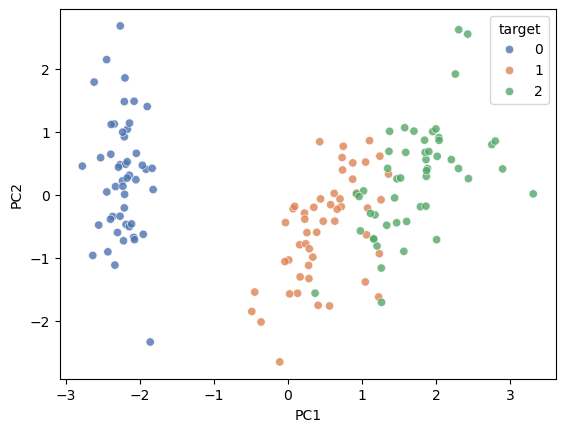

In [14]:
# 2 3 4 단계 : PCA 수행 및 데이터 변환
pca = PCA(n_components=2)
principleComponents =pca.fit_transform(X_scaled)

# 주성분 분석결과를 DataFrame으로 변환
pc_df = pd.DataFrame(data=principleComponents,columns=['PC1','PC2'])
pc_df['target'] = df.target
pc_df

# 각 주성분이 설명하는 분산의 양(고유값의 중요도)
print(pca.explained_variance_ratio_)

# 시각화
sns.scatterplot(data= pc_df, x = 'PC1', y = 'PC2', hue = 'target', alpha = 0.8,palette='deep')
plt.show()

In [15]:
from sklearn import datasets
# 데이터 셋
datasets.load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
import numpy as np
# 1. 적절한 데이터 전처리
# 2. 모델을 적용해서 score를 확인

################################
# 1. 적절한 데이터 전처리된 데이터를 가지고 PCA로 주성분을 적당한 개수로 설정해서 데이터를 변환
                                                    # 최적의 n_components 값을 구하는 법 gpt에게 물어보기 ^
# 2. 모델을 제공해서 score를 확인

In [16]:
diabetes = datasets.load_diabetes()
X = diabetes.data       # 10개 feature
y = diabetes.target     # 당뇨 진행 정도

# DataFrame으로 변환 (편의를 위해)
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

누적 분산 비율: [0.40242108 0.55165304 0.67224967 0.76779731 0.83401545 0.89428716
 0.94794372 0.99131192 0.99914393 1.        ]
최적 n_components: 7


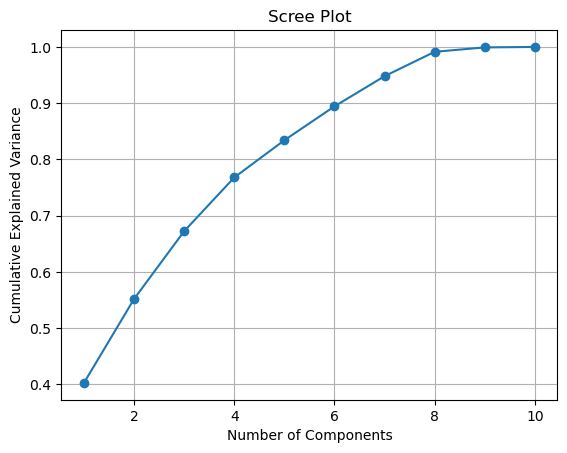

In [18]:
# 모든 주성분을 계산
pca_full = PCA()
pca_full.fit(X)

# 누적 분산 비율
cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
print("누적 분산 비율:", cumulative_variance)

# 90% 분산 설명에 필요한 주성분 수
n_components_opt = (cumulative_variance >= 0.9).argmax() + 1
print("최적 n_components:", n_components_opt)

# 시각화
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


각 주성분 설명 분산 비율: [0.40242108 0.14923197 0.12059663 0.09554764 0.06621814 0.06027171
 0.05365657]


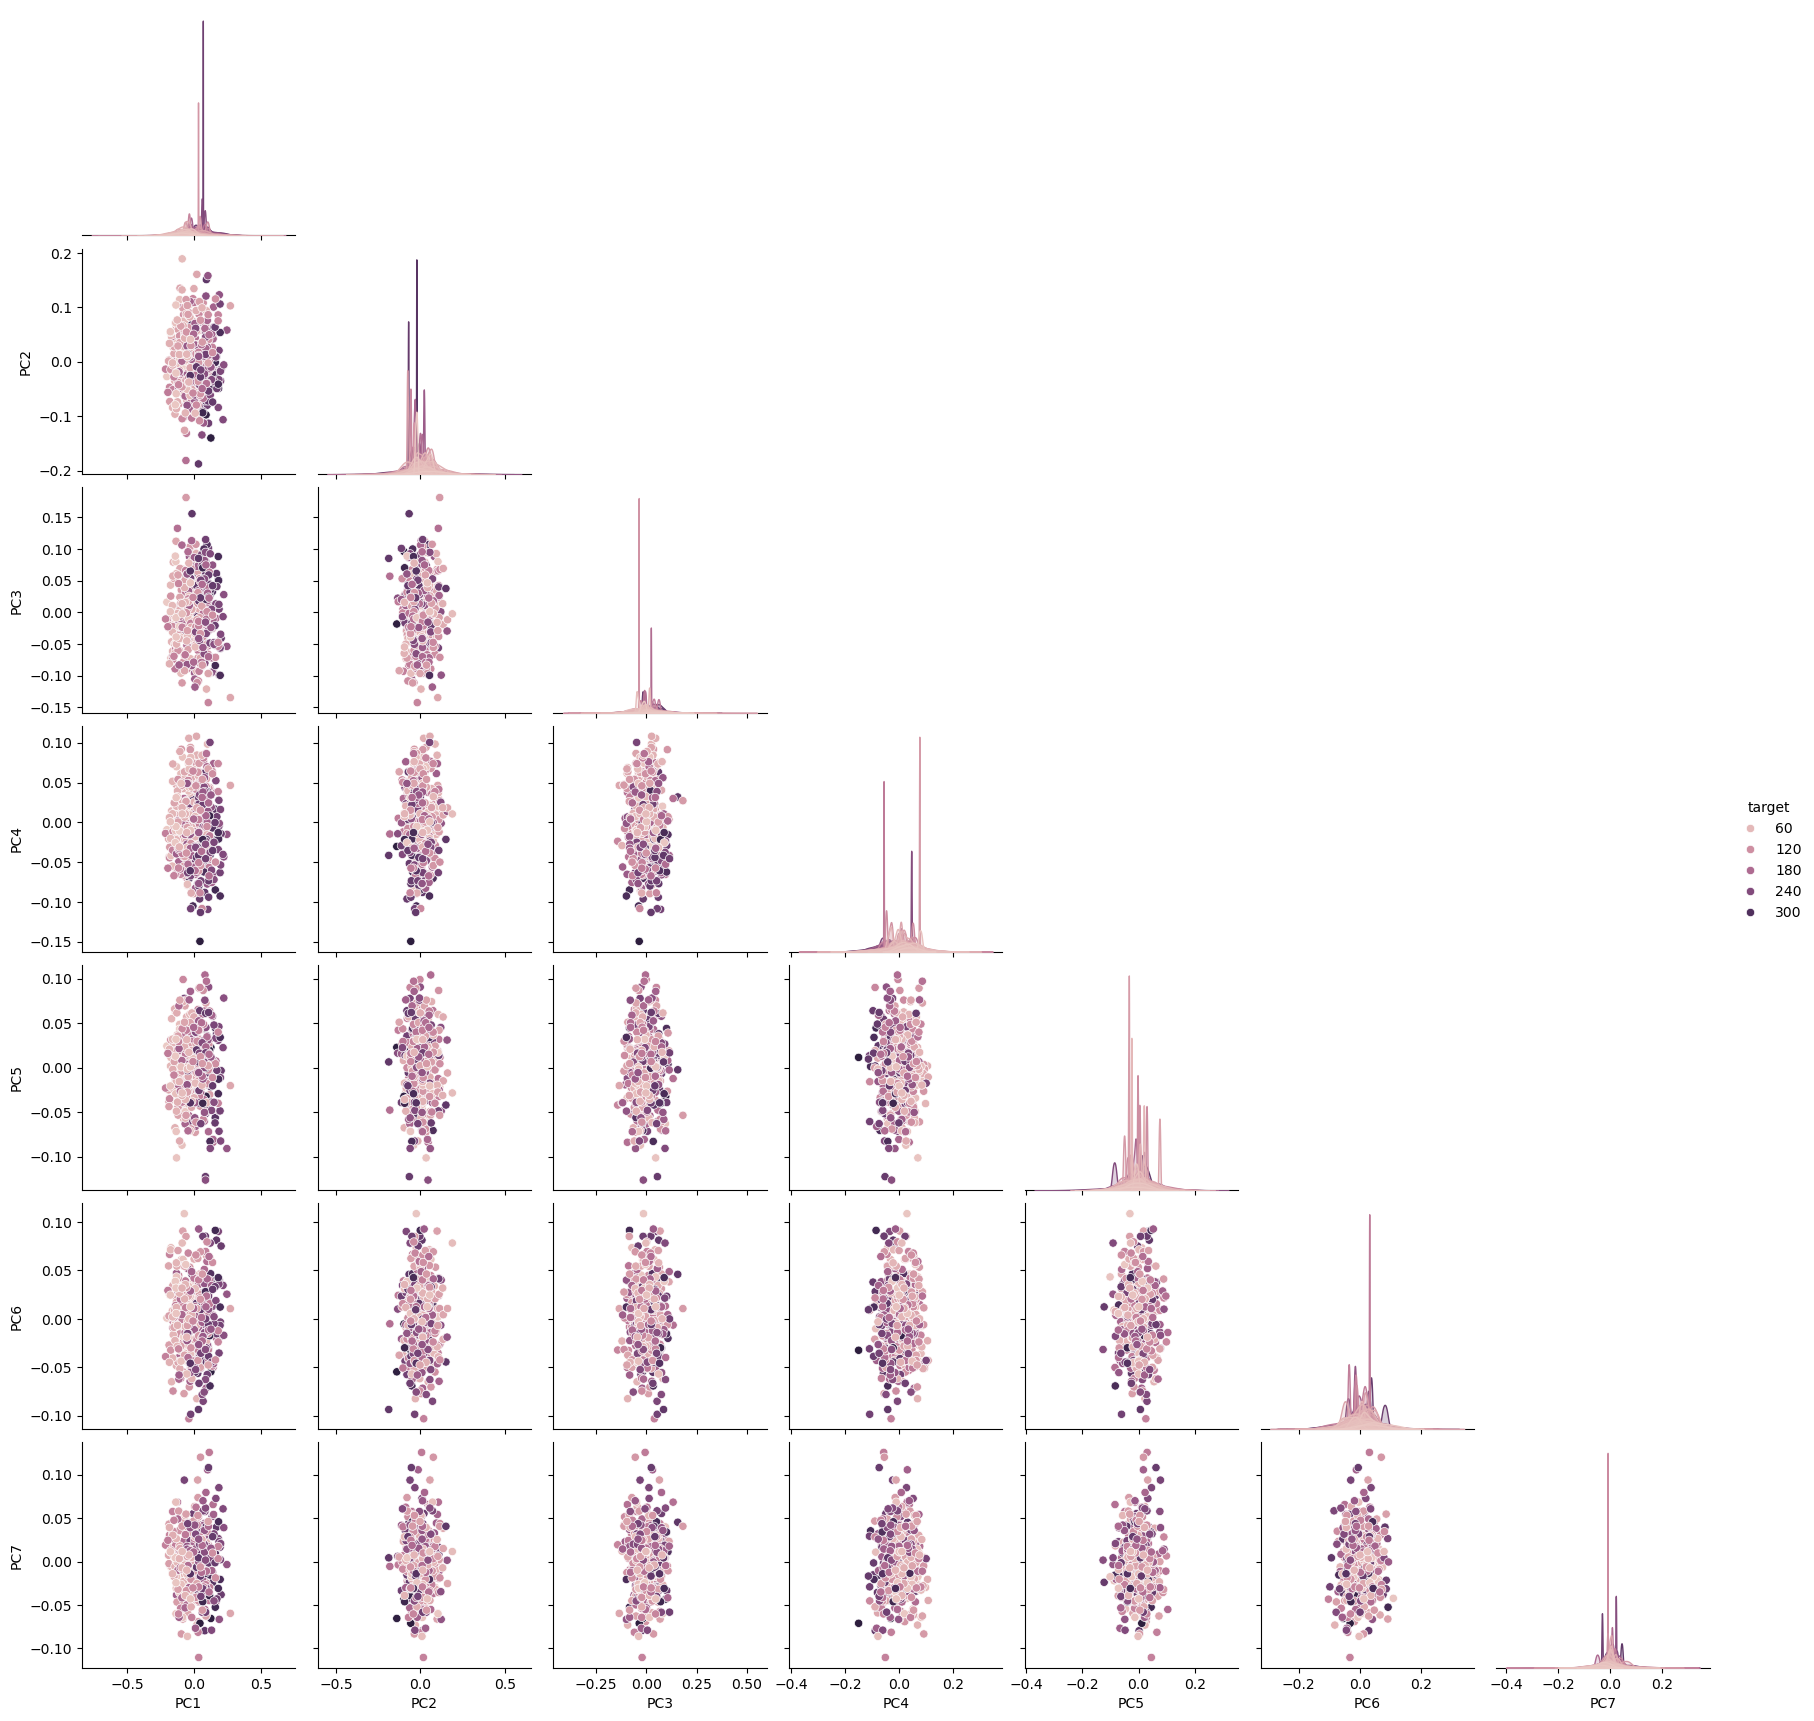

In [17]:
pca = PCA(n_components=7)
principleComponents = pca.fit_transform(X)

# DataFrame으로 변환
pc_df = pd.DataFrame(data=principleComponents, columns=['PC1','PC2','PC3','PC4','PC5','PC6','PC7'])
pc_df['target'] = y

# 각 주성분의 설명 분산 비율
print("각 주성분 설명 분산 비율:", pca.explained_variance_ratio_)

# 시각화
sns.pairplot(pc_df, vars=[f'PC{i+1}' for i in range(7)], hue='target', corner=True)
plt.show()

In [ ]:
# 데이터 분류
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y)

# 분류 모델 SGD
from sklearn.neighbors import KNeighborsClassifier


ValueError: Found input variables with inconsistent numbers of samples: [149, 442]